# 05. 취소 및 탑승 전환 분석

접수건이 취소 또는 실제 탑승으로 이어지는 비중을 시간대/요일 기준으로 분석한다.


In [2]:
import json
import platform
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# 한글 폰트 설정
if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

# 프로젝트 루트 설정
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

# 서울 자치구 지도 데이터 로드
map_path = project_root / "data" / "raw" / "seoul_municipalities_geo_simple.json"

with open(map_path, encoding="utf-8") as map_file:
    seoul_map = json.load(map_file)

In [3]:
df_request = pd.read_csv(
    '../data/processed/서울시설공단_장애인콜택시 접수일시_월주차_파생컬럼_20251231.csv',
    parse_dates=['접수일시', '접수일자']
)

df_request.info()
df_request.head()


<class 'pandas.DataFrame'>
RangeIndex: 1722490 entries, 0 to 1722489
Data columns (total 22 columns):
 #   Column   Dtype         
---  ------   -----         
 0   접수일시     datetime64[us]
 1   예정일시     str           
 2   배차일시     str           
 3   승차일시     str           
 4   하차일시     str           
 5   취소일시     str           
 6   출발구      str           
 7   출발동      str           
 8   목적구      str           
 9   목적동      str           
 10  이용목적     str           
 11  요금       float64       
 12  승차거리     int64         
 13  차량구분     str           
 14  장애유형     str           
 15  접수일자     datetime64[us]
 16  접수시간     str           
 17  접수시간대    int64         
 18  접수요일     str           
 19  접수월      str           
 20  접수ISO주차  int64         
 21  접수월주차    str           
dtypes: datetime64[us](2), float64(1), int64(3), str(16)
memory usage: 289.1 MB


,접수일시,예정일시,배차일시,승차일시,하차일시,취소일시,출발구,출발동,목적구,목적동,...,승차거리,차량구분,장애유형,접수일자,접수시간,접수시간대,접수요일,접수월,접수ISO주차,접수월주차
0,2025-01-01 00:01:26.127,2025-01-01 00:01:26.127,2025-01-01 00:27:31.307,2025-01-01 00:49:52.967,2025-01-01 01:35:06.747,NaN,용산구,남영동,강북구,수유제2동,...,17667,특장차,지체,2025-01-01,00:01:26,0,수요일,2025-01,1,2025-01-1주차
1,2025-01-01 00:03:10.557,2025-01-01 00:03:10.557,2025-01-01 00:14:39.800,NaN,NaN,2025-01-01 00:21:15.000,영등포구,여의동,강서구,화곡제6동,...,0,특장차,뇌병,2025-01-01,00:03:10,0,수요일,2025-01,1,2025-01-1주차
2,2025-01-01 00:03:31.230,2025-01-01 00:04:00.000,2025-01-01 00:19:41.900,2025-01-01 00:36:18.433,2025-01-01 00:49:45.857,NaN,노원구,상계5동,노원구,하계1동,...,2910,특장차,뇌병,2025-01-01,00:03:31,0,수요일,2025-01,1,2025-01-1주차
3,2025-01-01 00:03:40.573,2025-01-01 00:04:00.000,2025-01-01 00:33:41.650,2025-01-01 00:53:48.440,2025-01-01 01:33:38.120,NaN,영등포구,당산제1동,중구,명동,...,10421,특장차,지체,2025-01-01,00:03:40,0,수요일,2025-01,1,2025-01-1주차
4,2025-01-01 00:04:15.077,2025-01-01 00:04:15.077,2025-01-01 00:06:33.790,2025-01-01 00:40:07.840,2025-01-01 01:10:15.110,NaN,송파구,오금동,서초구,내곡동,...,11943,특장차,지체,2025-01-01,00:04:15,0,수요일,2025-01,1,2025-01-1주차


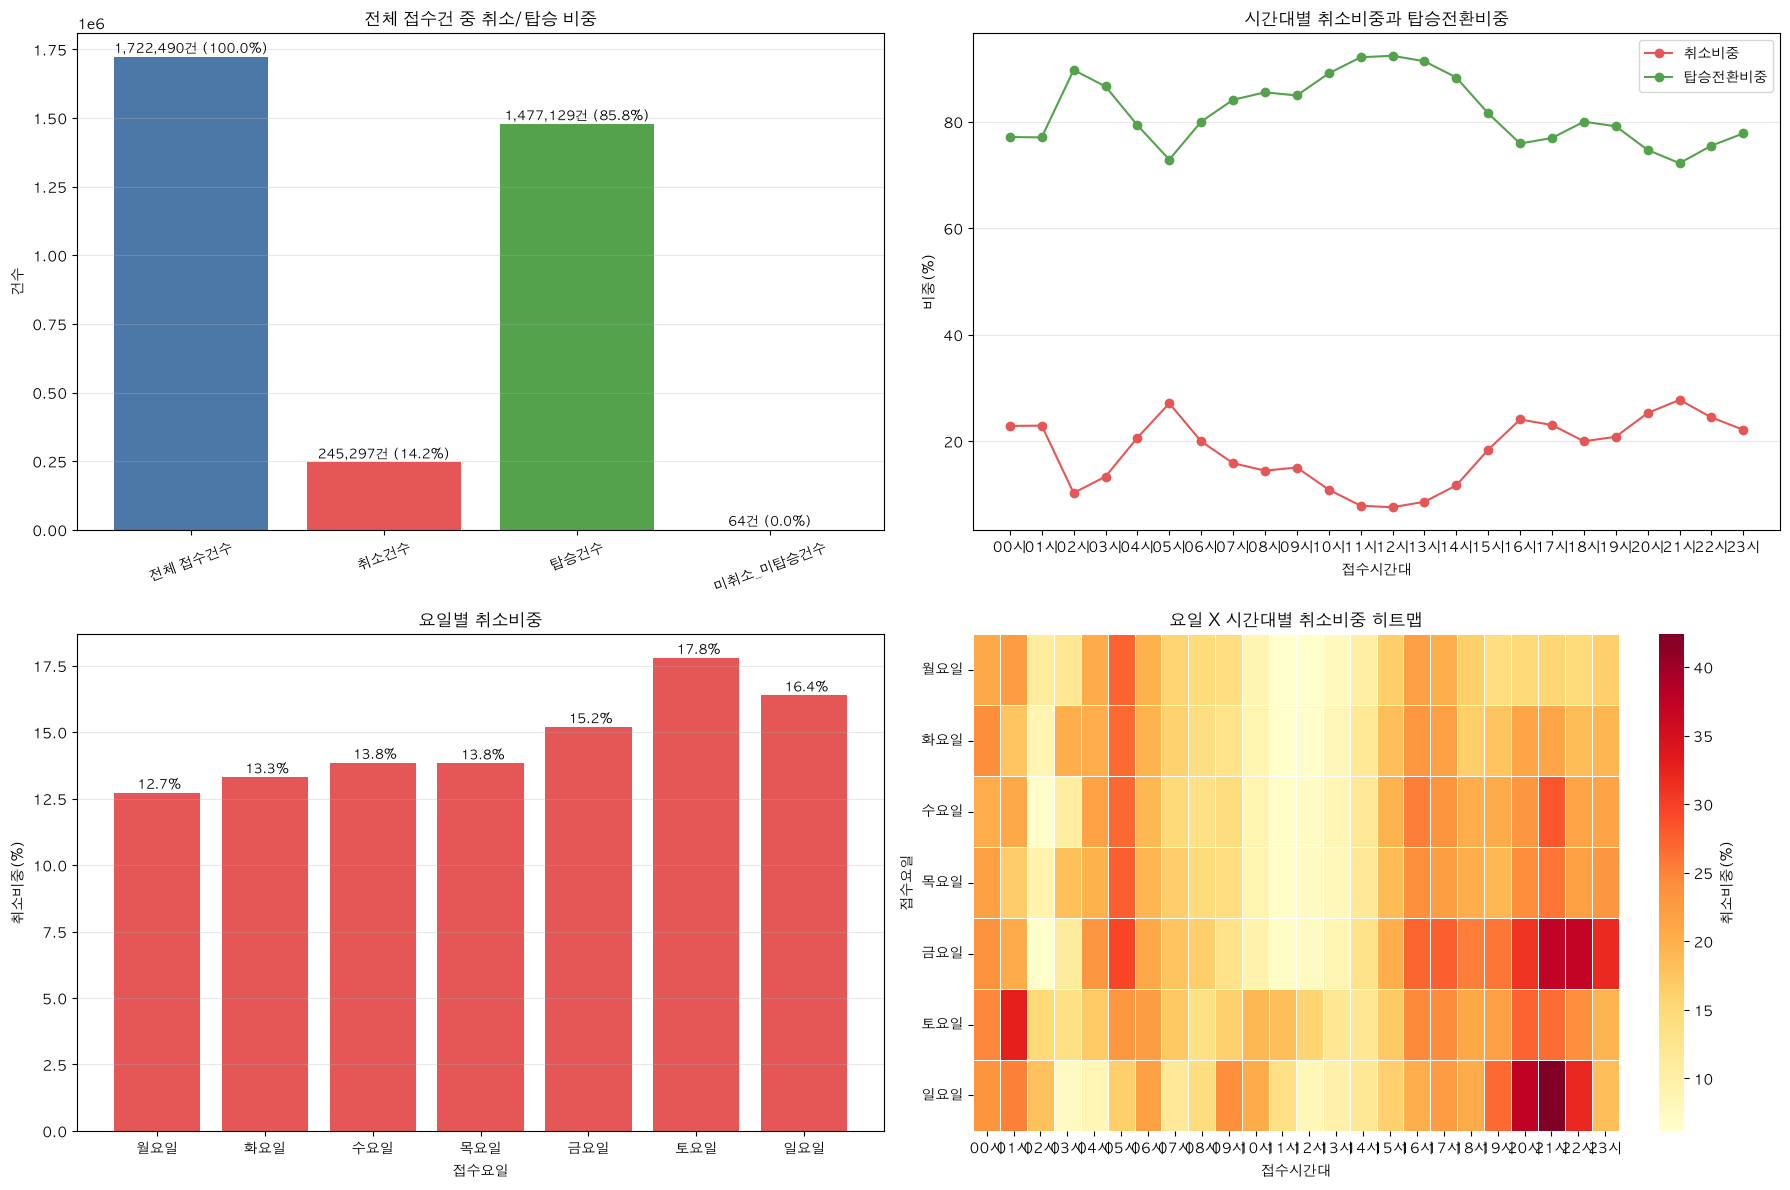

전체 취소/탑승 요약


,구분,건수,비중(%)
0,전체 접수건수,1722490,100.000000
1,취소건수,245297,14.240837
2,탑승건수,1477129,85.755447
3,미취소_미탑승건수,64,0.003716


시간대별 취소비중 상위 10


,접수시간대,전체접수건수,취소건수,탑승건수,접수시간대_label,취소비중(%),탑승전환비중(%)
21,21,11449,3180,8268,21시,27.775352,72.215914
5,5,22971,6229,16742,05시,27.116799,72.883201
20,20,19873,5027,14846,20시,25.295627,74.704373
22,22,6306,1543,4762,22시,24.468760,75.515382
16,16,97434,23463,73969,16시,24.080916,75.917031
17,17,61075,14077,46996,17시,23.048711,76.948015
1,1,1330,305,1025,01시,22.932331,77.067669
0,0,2186,500,1686,00시,22.872827,77.127173
23,23,3947,874,3071,23시,22.143400,77.805929
19,19,25370,5286,20081,19시,20.835633,79.152542


요일별 취소비중


,접수요일,전체접수건수,취소건수,탑승건수,취소비중(%),탑승전환비중(%)
0,월요일,296870,37754,259093,12.717351,87.274901
1,화요일,296271,39408,256852,13.301336,86.694952
2,수요일,306416,42426,263982,13.845883,86.151506
3,목요일,290893,40213,250674,13.823983,86.173954
4,금요일,287647,43683,243949,15.186322,84.808463
5,토요일,126327,22474,103852,17.790338,82.208871
6,일요일,118066,19339,98727,16.379821,83.620179


접수 수요는 많지만 탑승전환비중이 낮은 요일 X 시간대 후보


,접수요일,접수시간대,전체접수건수,취소건수,탑승건수,취소비중(%),탑승전환비중(%),접수시간대_label
0,금요일,15,30094,6078,24016,20.196717,79.803283,15시
1,수요일,15,33300,6503,26797,19.528529,80.471471,15시
2,목요일,15,30910,5773,25136,18.676804,81.319961,15시
3,화요일,15,31495,5769,25726,18.317193,81.682807,15시
4,금요일,7,18936,3347,15588,17.675327,82.319392,07시
5,목요일,7,22128,3664,18463,16.558207,83.437274,07시
6,월요일,15,32290,5318,26971,16.469495,83.527408,15시
7,금요일,8,21113,3459,17654,16.383271,83.616729,08시
8,화요일,7,22699,3645,19054,16.057976,83.942024,07시
9,월요일,7,23753,3721,20031,15.665390,84.330400,07시


In [5]:
# CANCEL_REQUEST_DEMAND_ANALYSIS_JSON_CELL
# 6.7 취소 여부별 접수 수요 분석
if 'df_request' not in globals():
    df_request = pd.read_csv(
        'data/서울시설공단_장애인콜택시 접수일시_월주차_파생컬럼_20251231.csv'
    )

weekday_order = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']

df_cancel_analysis = df_request.copy()
df_cancel_analysis['취소여부'] = df_cancel_analysis['취소일시'].notna()
df_cancel_analysis['탑승여부'] = df_cancel_analysis['승차일시'].notna()
df_cancel_analysis['접수시간대_label'] = df_cancel_analysis['접수시간대'].map(
    lambda x: f'{int(x):02d}시' if pd.notna(x) else pd.NA
)

overall_cancel_summary = pd.DataFrame({
    '구분': ['전체 접수건수', '취소건수', '탑승건수', '미취소_미탑승건수'],
    '건수': [
        len(df_cancel_analysis),
        df_cancel_analysis['취소여부'].sum(),
        df_cancel_analysis['탑승여부'].sum(),
        ((~df_cancel_analysis['취소여부']) & (~df_cancel_analysis['탑승여부'])).sum(),
    ]
})
overall_cancel_summary['비중(%)'] = overall_cancel_summary['건수'] / len(df_cancel_analysis) * 100

time_cancel_summary = (
    df_cancel_analysis
    .dropna(subset=['접수시간대'])
    .groupby('접수시간대')
    .agg(
        전체접수건수=('접수일시', 'size'),
        취소건수=('취소여부', 'sum'),
        탑승건수=('탑승여부', 'sum')
    )
    .reindex(range(24), fill_value=0)
    .reset_index()
)
time_cancel_summary['접수시간대_label'] = time_cancel_summary['접수시간대'].map(lambda x: f'{int(x):02d}시')
time_cancel_summary['취소비중(%)'] = time_cancel_summary['취소건수'] / time_cancel_summary['전체접수건수'] * 100
time_cancel_summary['탑승전환비중(%)'] = time_cancel_summary['탑승건수'] / time_cancel_summary['전체접수건수'] * 100

day_cancel_summary = (
    df_cancel_analysis
    .dropna(subset=['접수요일'])
    .groupby('접수요일')
    .agg(
        전체접수건수=('접수일시', 'size'),
        취소건수=('취소여부', 'sum'),
        탑승건수=('탑승여부', 'sum')
    )
    .reindex(weekday_order)
    .reset_index()
)
day_cancel_summary['취소비중(%)'] = day_cancel_summary['취소건수'] / day_cancel_summary['전체접수건수'] * 100
day_cancel_summary['탑승전환비중(%)'] = day_cancel_summary['탑승건수'] / day_cancel_summary['전체접수건수'] * 100

weekday_hour_cancel_summary = (
    df_cancel_analysis
    .dropna(subset=['접수요일', '접수시간대'])
    .groupby(['접수요일', '접수시간대'])
    .agg(
        전체접수건수=('접수일시', 'size'),
        취소건수=('취소여부', 'sum'),
        탑승건수=('탑승여부', 'sum')
    )
    .reset_index()
)
weekday_hour_cancel_summary['취소비중(%)'] = weekday_hour_cancel_summary['취소건수'] / weekday_hour_cancel_summary['전체접수건수'] * 100
weekday_hour_cancel_summary['탑승전환비중(%)'] = weekday_hour_cancel_summary['탑승건수'] / weekday_hour_cancel_summary['전체접수건수'] * 100
weekday_hour_cancel_summary['접수시간대_label'] = weekday_hour_cancel_summary['접수시간대'].map(lambda x: f'{int(x):02d}시')

high_request_low_boarding = (
    weekday_hour_cancel_summary[
        weekday_hour_cancel_summary['전체접수건수'] >= weekday_hour_cancel_summary['전체접수건수'].quantile(0.75)
    ]
    .sort_values(['탑승전환비중(%)', '전체접수건수'], ascending=[True, False])
    .reset_index(drop=True)
)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0, 0].bar(
    overall_cancel_summary['구분'],
    overall_cancel_summary['건수'],
    color=['#4c78a8', '#e45756', '#54a24b', '#b279a2']
)
axes[0, 0].set_title('전체 접수건 중 취소/탑승 비중')
axes[0, 0].set_ylabel('건수')
axes[0, 0].tick_params(axis='x', rotation=20)
axes[0, 0].grid(axis='y', alpha=0.3)
for index, row in overall_cancel_summary.iterrows():
    label_text = f"{row['건수']:,.0f}건 ({row['비중(%)']:.1f}%)"
    axes[0, 0].text(index, row['건수'], label_text, ha='center', va='bottom', fontsize=9)

axes[0, 1].plot(time_cancel_summary['접수시간대_label'], time_cancel_summary['취소비중(%)'], marker='o', color='#e45756', label='취소비중')
axes[0, 1].plot(time_cancel_summary['접수시간대_label'], time_cancel_summary['탑승전환비중(%)'], marker='o', color='#54a24b', label='탑승전환비중')
axes[0, 1].set_title('시간대별 취소비중과 탑승전환비중')
axes[0, 1].set_xlabel('접수시간대')
axes[0, 1].set_ylabel('비중(%)')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

axes[1, 0].bar(day_cancel_summary['접수요일'], day_cancel_summary['취소비중(%)'], color='#e45756')
axes[1, 0].set_title('요일별 취소비중')
axes[1, 0].set_xlabel('접수요일')
axes[1, 0].set_ylabel('취소비중(%)')
axes[1, 0].tick_params(axis='x', rotation=0)
axes[1, 0].grid(axis='y', alpha=0.3)
for index, value in enumerate(day_cancel_summary['취소비중(%)']):
    axes[1, 0].text(index, value, f' {value:.1f}%', ha='center', va='bottom', fontsize=9)

cancel_rate_pivot = (
    weekday_hour_cancel_summary
    .pivot_table(index='접수요일', columns='접수시간대_label', values='취소비중(%)', aggfunc='mean')
    .reindex(weekday_order)
)
cancel_rate_pivot = cancel_rate_pivot[[f'{hour:02d}시' for hour in range(24) if f'{hour:02d}시' in cancel_rate_pivot.columns]]

sns.heatmap(
    cancel_rate_pivot,
    ax=axes[1, 1],
    cmap='YlOrRd',
    linewidths=0.4,
    cbar_kws={'label': '취소비중(%)'}
)
axes[1, 1].set_title('요일 X 시간대별 취소비중 히트맵')
axes[1, 1].set_xlabel('접수시간대')
axes[1, 1].set_ylabel('접수요일')
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

print('전체 취소/탑승 요약')
display(overall_cancel_summary)

print('시간대별 취소비중 상위 10')
display(time_cancel_summary.sort_values('취소비중(%)', ascending=False).head(10))

print('요일별 취소비중')
display(day_cancel_summary)

print('접수 수요는 많지만 탑승전환비중이 낮은 요일 X 시간대 후보')
display(high_request_low_boarding.head(20))

